### Quiz

In [53]:
import pandas as pd

df = pd.read_csv("../data/fifa.csv", low_memory=False)

def clean_height(height):
    if "inches" in height:
        return float(height.replace(" inches", ""))*2.54
    else:
        return float(height.replace(" centimetres", ""))

def clean_wage(wage):
    if "K" in wage:
        return float(wage.replace("K", "000").replace("€", ""))
    else:
        return float(wage.replace("€", ""))

df["Height"] = df["Height"].map(clean_height)
df["Weight"] = df["Weight"].str.replace("lbs", "").astype("float")
df["Wage"] = df["Wage"].map(clean_wage)

#### Part 1

Run the code block above to get a cleaned version of the FIFA dataset in `fifa.csv`. Using this cleaned dataset, create dummy variables for the `A/W` variable (attacking work rate).

In [54]:
df = pd.get_dummies(data=df, columns=["A/W"], drop_first=True, dtype="int")
df.head()

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits,A/W_Low,A/W_Medium
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,...,5 ★,85,92,91,95,38,65,372,0,1
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,...,5 ★,89,93,81,89,35,77,344,0,0
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,...,3 ★,87,92,78,90,52,90,86,0,1
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,...,4 ★,76,86,93,88,64,78,163,0,0
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,...,5 ★,91,85,86,94,36,59,273,0,0


#### Part 2

Fit a multiple linear regression model using `Height`, `Weight` and the dummy variables for `A/W` as predictor variables and the log of `Wage` as a response variable.

In [57]:
import numpy as np
from sklearn.linear_model import LinearRegression

df["log_Wage"]=np.log1p(df["Wage"])
mlr_model=LinearRegression()
X_mlr=df[["Height", "Weight", "A/W_Low", "A/W_Medium"]]
mlr_model.fit(X_mlr, df["log_Wage"])

LinearRegression()

#### Part 3

Print out the intercept and coefficients for the model fit in Part 2.

In [58]:
print(mlr_model.intercept_)
print(mlr_model.coef_)

7.1431053030240355
[-0.00487964  0.01297125 -0.66667364 -0.58665904]


#### Part 4

Get predictions for the response variable using the model fit in Part 2 and then compute the RMSE.

In [60]:
from sklearn.metrics import root_mean_squared_error

y = df["log_Wage"]
mlr_preds = mlr_model.predict(X_mlr)
root_mean_squared_error(mlr_preds, y)

1.5895490117456077

#### Part 5

Create a residual scatter plot of the predicted values on the x-axis and the residuals on the y-axis.

<Axes: ylabel='log_Wage'>

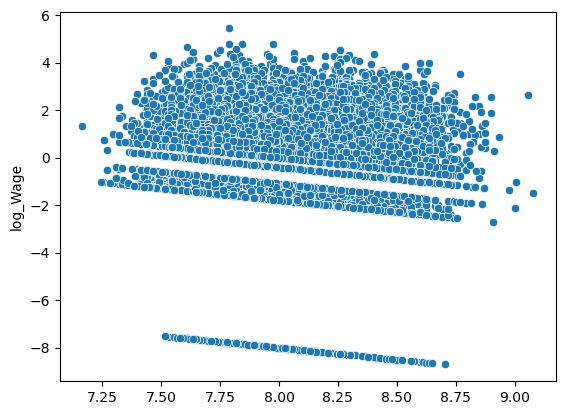

In [61]:
resids = y - mlr_preds
sns.scatterplot(data=df, x=mlr_preds, y=resids)

#### Part 6

Does there appear to be a violation of linearity for this model?

There does not seem to be a violation of linearity as most values follow a linear trend locally